In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
raw_url = "https://raw.githubusercontent.com/NepalStockData/Nepal_Stock_Data/main/Nepse_Data/Hydro_Power/DORDI.csv"

# Load into DataFrame
df = pd.read_csv(raw_url)

In [8]:
df.head()

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,1,2026-09-09,240.0,245.0,235.1,240.0,0.00,"17,869.00","4,256,114.50"
1,2,2026-09-07,237.0,241.0,237.0,240.0,1.39,"7,723.00","1,850,781.00"
2,3,2026-09-03,244.0,244.0,235.7,236.7,-0.96,"9,039.00","2,146,432.50"
3,4,2026-09-02,233.6,240.0,233.6,239.0,1.06,"8,694.00","2,065,326.80"
4,5,2026-09-01,233.1,241.5,233.1,236.5,0.17,"21,839.00","5,206,928.10"


In [9]:
df.iloc[:,1:]

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,2026-09-09,240.0,245.0,235.1,240.0,0.00,"17,869.00","4,256,114.50"
1,2026-09-07,237.0,241.0,237.0,240.0,1.39,"7,723.00","1,850,781.00"
2,2026-09-03,244.0,244.0,235.7,236.7,-0.96,"9,039.00","2,146,432.50"
3,2026-09-02,233.6,240.0,233.6,239.0,1.06,"8,694.00","2,065,326.80"
4,2026-09-01,233.1,241.5,233.1,236.5,0.17,"21,839.00","5,206,928.10"
...,...,...,...,...,...,...,...,...
952,2022-07-19,302.0,312.0,297.5,299.1,-1.29,"13,090.00","3,969,883.00"
953,2022-07-18,294.0,308.0,290.2,303.0,1.00,"14,521.00","4,393,702.50"
954,2022-07-17,309.0,309.0,292.1,300.0,-2.98,"18,500.00","5,555,379.00"
955,2022-07-15,320.0,320.0,294.0,309.2,-1.84,"27,911.00","8,516,335.80"


In [10]:
df.shape

(957, 9)

In [11]:
print(df.columns.tolist())

['S.N.', 'Date', 'Open', 'High', 'Low', 'Ltp', '% Change', 'Qty', 'Turnover']


In [12]:
cols = ['Open', 'High', 'Low', '% Change', 'Qty', 'Turnover']

for col in cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', ''),
    )
    

In [13]:
df.loc[df['High'].idxmax(), ['Date', 'Ltp']]

Date    2025-02-06
Ltp          658.0
Name: 363, dtype: object

In [14]:
df.loc[df['Low'].idxmin(), ['Date','Ltp']]

Date    2023-09-11
Ltp          205.0
Name: 680, dtype: object

In [15]:
#75 crore turnover in single day is incredible
df.loc[df['Turnover'].idxmax(), ['Date','Turnover','Ltp','% Change']]

Date         2025-06-22
Turnover    757397371.4
Ltp              360.83
% Change          -3.59
Name: 277, dtype: object

In [16]:
df.isnull().sum()

S.N.        0
Date        0
Open        0
High        0
Low         0
Ltp         0
% Change    0
Qty         0
Turnover    0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.dtypes

S.N.          int64
Date         object
Open        float64
High        float64
Low         float64
Ltp         float64
% Change    float64
Qty         float64
Turnover    float64
dtype: object

In [19]:
df.describe()

,S.N.,Open,High,Low,Ltp,% Change,Qty,Turnover
count,957.000000,957.000000,957.000000,957.000000,957.000000,957.000000,9.570000e+02,9.570000e+02
mean,479.000000,334.841588,344.119854,327.595298,335.651212,0.070355,5.237416e+04,1.782653e+07
std,276.406404,103.161419,106.645195,100.217258,102.898756,2.846636,1.084127e+05,3.521713e+07
min,1.000000,192.100000,197.900000,191.600000,195.000000,-8.340000,4.680000e+02,9.501000e+04
25%,240.000000,255.000000,261.000000,251.000000,255.000000,-1.670000,9.039000e+03,2.851431e+06
50%,479.000000,300.000000,308.000000,292.300000,299.500000,-0.250000,2.245900e+04,7.387569e+06
75%,718.000000,410.000000,422.000000,400.000000,411.900000,1.420000,5.547100e+04,2.117374e+07
max,957.000000,673.200000,696.000000,658.000000,660.000000,10.000000,2.183822e+06,7.573974e+08


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   S.N.      957 non-null    int64  
 1   Date      957 non-null    object 
 2   Open      957 non-null    float64
 3   High      957 non-null    float64
 4   Low       957 non-null    float64
 5   Ltp       957 non-null    float64
 6   % Change  957 non-null    float64
 7   Qty       957 non-null    float64
 8   Turnover  957 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 67.4+ KB


In [21]:
df['Date'] = pd.to_datetime(df['Date'])

In [22]:
df.dtypes

S.N.                 int64
Date        datetime64[ns]
Open               float64
High               float64
Low                float64
Ltp                float64
% Change           float64
Qty                float64
Turnover           float64
dtype: object

In [23]:
df = df.sort_values('Date').reset_index(drop=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   S.N.      957 non-null    int64         
 1   Date      957 non-null    datetime64[ns]
 2   Open      957 non-null    float64       
 3   High      957 non-null    float64       
 4   Low       957 non-null    float64       
 5   Ltp       957 non-null    float64       
 6   % Change  957 non-null    float64       
 7   Qty       957 non-null    float64       
 8   Turnover  957 non-null    float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 67.4 KB


In [25]:
print('First date:', df['Date'].min())

First date: 2022-07-14 00:00:00


In [26]:
print('Last_Date:',df['Date'].max())

Last_Date: 2026-09-09 00:00:00


In [27]:
print("Trading_Days:", len(df))

Trading_Days: 957


In [28]:
duration = df['Date'].max() - df['Date'].min()
print(duration)

1518 days 00:00:00


In [29]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
S.N.,957.0,479.0,1.0,240.0,479.0,718.0,957.0,276.406404
Date,957,2024-08-07 03:29:09.216301056,2022-07-14 00:00:00,2023-07-18 00:00:00,2024-07-31 00:00:00,2025-08-14 00:00:00,2026-09-09 00:00:00,NaN
Open,957.0,334.841588,192.1,255.0,300.0,410.0,673.2,103.161419
High,957.0,344.119854,197.9,261.0,308.0,422.0,696.0,106.645195
Low,957.0,327.595298,191.6,251.0,292.3,400.0,658.0,100.217258
Ltp,957.0,335.651212,195.0,255.0,299.5,411.9,660.0,102.898756
% Change,957.0,0.070355,-8.34,-1.67,-0.25,1.42,10.0,2.846636
Qty,957.0,52374.16092,468.0,9039.0,22459.0,55471.0,2183822.0,108412.709114
Turnover,957.0,17826529.634901,95010.0,2851431.0,7387568.8,21173740.6,757397371.4,35217132.272842


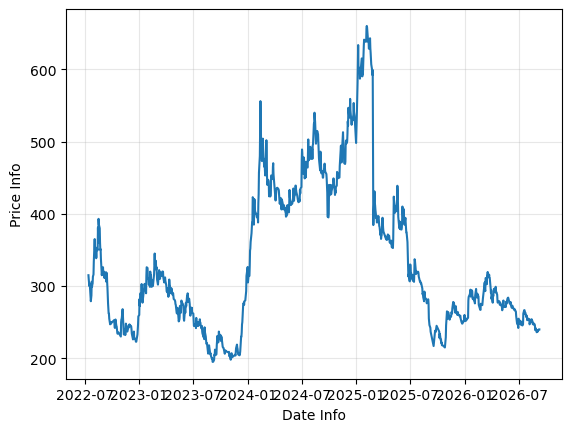

In [30]:
plt.plot(df['Date'], df['Ltp'])
plt.xlabel("Date Info")
plt.ylabel("Price Info")
plt.grid(alpha=0.3)
plt.show()

In [31]:
df['Return'] = df['Ltp'].pct_change()

In [32]:
df.head()

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover,Return
0,957,2022-07-14,307.1,337.8,295.0,315.0,2.57,127582.0,40778668.7,NaN
1,956,2022-07-15,320.0,320.0,294.0,309.2,-1.84,27911.0,8516335.8,-0.018413
2,955,2022-07-17,309.0,309.0,292.1,300.0,-2.98,18500.0,5555379.0,-0.029754
3,954,2022-07-18,294.0,308.0,290.2,303.0,1.00,14521.0,4393702.5,0.010000
4,953,2022-07-19,302.0,312.0,297.5,299.1,-1.29,13090.0,3969883.0,-0.012871


In [33]:
df['Return_Pct'] = df['Return'] * 100

In [34]:
df.loc[df['Return_Pct'].idxmax(), ['Date','% Change', 'Ltp']]

Date        2023-12-17 00:00:00
% Change                   10.0
Ltp                       275.0
Name: 330, dtype: object

In [35]:
df['Direction'] = np.where(
    df['Return'] > 0,
    'Up',
    np.where(
        df['Return'] < 0,
        'Down',
        'Flat'
    )
)

In [36]:
df['Direction'].value_counts()

Direction
Down    514
Up      418
Flat     25
Name: count, dtype: int64

In [37]:
df['Direction'].value_counts(normalize=True) * 100

Direction
Down    53.709509
Up      43.678161
Flat     2.612330
Name: proportion, dtype: float64

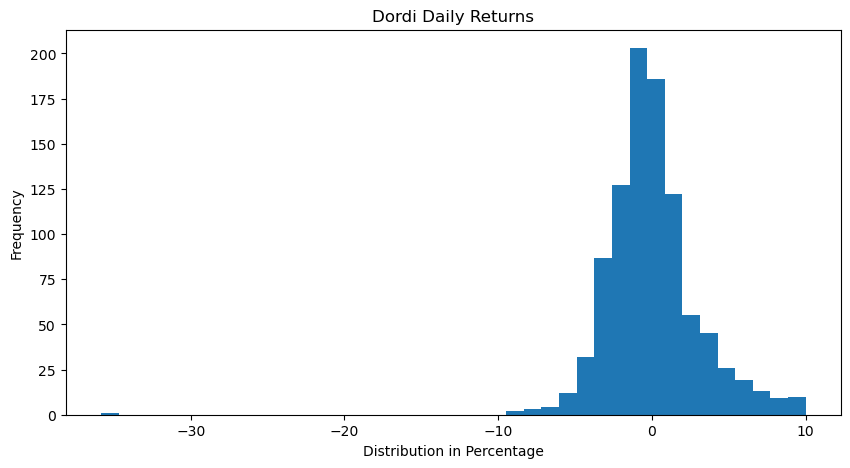

In [38]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['Return_Pct'].dropna(),
    bins=40
)

plt.title("Dordi Daily Returns")
plt.xlabel("Distribution in Percentage")
plt.ylabel("Frequency")

plt.show()


In [39]:
df['Return_Pct'].describe()

count    956.000000
mean       0.019917
std        3.057401
min      -35.826377
25%       -1.678319
50%       -0.251341
75%        1.392280
max       10.000000
Name: Return_Pct, dtype: float64

In [40]:
df['Return_Pct'].skew()

np.float64(-1.0666536782999347)

In [41]:
df['Return_Pct'].kurt()

np.float64(20.136463899069465)

In [42]:
df['Turnover'] = pd.to_numeric(df['Turnover'], errors='coerce')

In [43]:
df.nlargest(10, 'Turnover')[
    ['Date', 'Ltp', 'Turnover','Qty', 'Return_Pct']
    ]

,Date,Ltp,Turnover,Qty,Return_Pct
679,2025-06-22,360.83,757397371.4,2183822.0,-3.585838
802,2026-01-13,280.00,258260448.0,940424.0,9.375000
835,2026-03-12,311.00,218898120.2,714960.0,6.143345
803,2026-01-14,284.90,193032472.4,671118.0,1.750000
805,2026-01-20,295.00,180879545.7,611613.0,2.182196
818,2026-02-08,296.00,173811957.2,589154.0,3.135889
838,2026-03-17,314.90,172354385.5,558493.0,4.099174
839,2026-03-19,319.50,167626999.4,520092.0,1.460781
730,2025-09-02,255.03,144194009.4,561514.0,-7.315744
804,2026-01-18,288.70,135155586.6,468780.0,1.333801


In [44]:
df.nsmallest(10, '% Change')[
    ['Date','Ltp','Return_Pct','Qty']
    ]

,Date,Ltp,Return_Pct,Qty
735,2025-09-18,217.00,-8.342133,8170.0
352,2024-01-22,385.00,-8.333333,71953.0
513,2024-09-26,396.00,-7.692308,27363.0
730,2025-09-02,255.03,-7.315744,561514.0
53,2022-09-18,276.00,-7.226891,13875.0
382,2024-03-05,468.00,-6.735751,51301.0
339,2024-01-02,305.00,-6.556373,29657.0
206,2023-05-31,255.00,-6.422018,10529.0
371,2024-02-18,473.00,-6.150794,98075.0
195,2023-05-14,251.10,-5.919820,4108.0


In [45]:
df['Daily_Range'] = df['High'] - df['Low']

In [46]:
df['Daily_Range']

0      42.8
1      26.0
2      16.9
3      17.8
4      14.5
       ... 
952     8.4
953     6.4
954     8.3
955     4.0
956     9.9
Name: Daily_Range, Length: 957, dtype: float64

In [52]:
df['Range_Pct'] = (
    (df['High'] - df['Low']) / df['Open']
) * 100

In [54]:
df['Range_Pct']

0      13.936828
1       8.125000
2       5.469256
3       6.054422
4       4.801325
         ...    
952     3.603604
953     2.739726
954     3.401639
955     1.687764
956     4.125000
Name: Range_Pct, Length: 957, dtype: float64

In [56]:
df['Range_Pct'].mean()

np.float64(4.815121763940527)

In [59]:
df.nlargest(10, 'Range_Pct')[
    ['Date','Range_Pct','Ltp','Qty','High', 'Low','Open']
    ]

,Date,Range_Pct,Ltp,Qty,High,Low,Open
367,2024-02-12,20.000000,521.00,114969.0,528.0,432.0,480.0
679,2025-06-22,18.494624,360.83,2183822.0,407.9,339.1,372.0
350,2024-01-18,18.315018,423.00,78513.0,423.0,353.0,382.2
347,2024-01-14,18.258903,373.00,52785.0,389.6,325.0,353.8
112,2023-01-02,15.984848,282.00,16519.0,286.0,243.8,264.0
351,2024-01-21,14.698795,420.00,88419.0,442.0,381.0,415.0
0,2022-07-14,13.936828,315.00,127582.0,337.8,295.0,307.1
26,2022-08-15,13.877551,381.00,42081.0,384.0,336.4,343.0
349,2024-01-17,13.637556,390.00,67355.0,412.0,360.0,381.3
366,2024-02-11,13.446504,480.00,148503.0,482.0,421.8,447.7


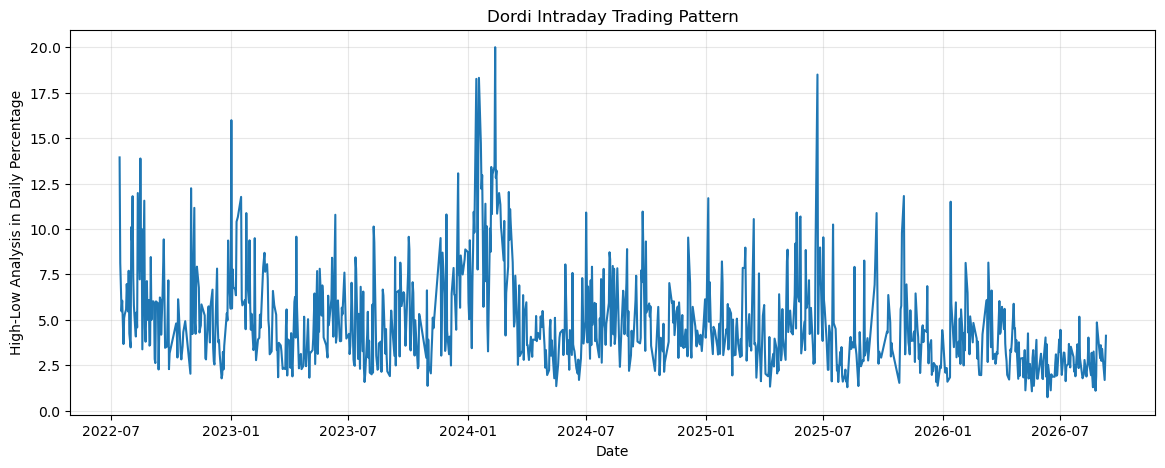

In [61]:
plt.figure(figsize=(14,5))

plt.plot(
    df['Date'],
    df['Range_Pct']
)

plt.title('Dordi Intraday Trading Pattern')
plt.xlabel('Date')
plt.ylabel('High-Low Analysis in Daily Percentage')
plt.grid(alpha=0.3)

plt.show()

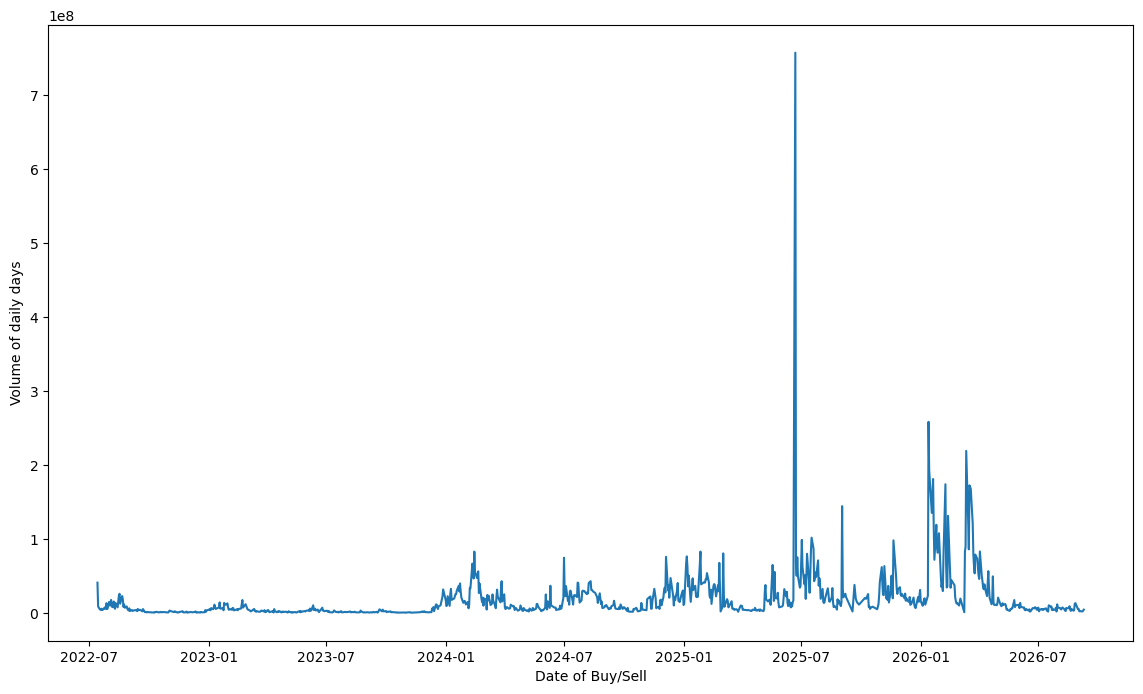

In [75]:
plt.figure(figsize=(14,8))

plt.plot(
    df['Date'], 
    df['Turnover']
)
plt.xlabel("Date of Buy/Sell")
plt.ylabel("Volume of daily days")
plt.show()

In [79]:
df.nlargest(
    10, 
    'Turnover'
)[
    ['Date','Ltp','% Change']
]

,Date,Ltp,% Change
679,2025-06-22,360.83,-3.59
802,2026-01-13,280.00,9.38
835,2026-03-12,311.00,6.14
803,2026-01-14,284.90,1.75
805,2026-01-20,295.00,2.18
818,2026-02-08,296.00,3.14
838,2026-03-17,314.90,4.10
839,2026-03-19,319.50,1.46
730,2025-09-02,255.03,-7.32
804,2026-01-18,288.70,1.33


In [84]:
#Finding out absolute Return
df['Abs_Return'] = df['Return_Pct'].abs()

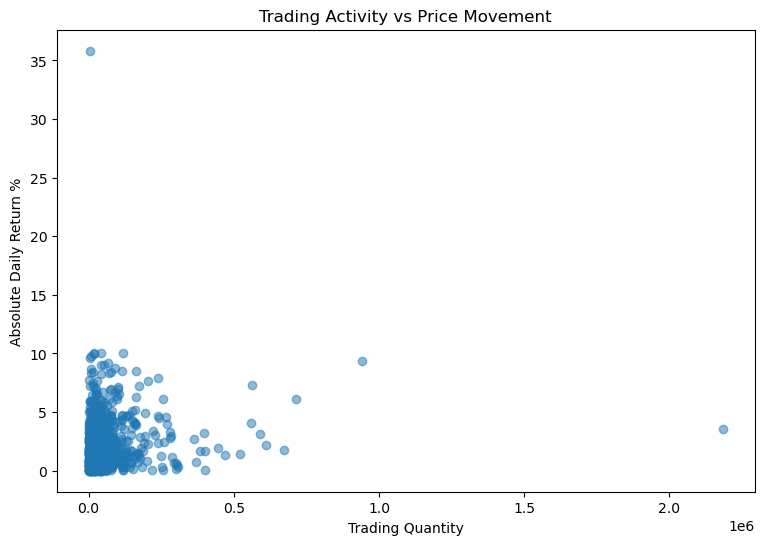

In [81]:
plt.figure(figsize=(9,6))

plt.scatter(
    df['Qty'],
    df['Abs_Return'],
    alpha=0.5
)
plt.xlabel('Trading Quantity')
plt.ylabel('Absolute Daily Return %')
plt.title('Trading Activity vs Price Movement')

plt.show()

In [82]:
df[
    ['Qty', 'Abs_Return']
].corr()

,Qty,Abs_Return
Qty,1.000000,0.120269
Abs_Return,0.120269,1.000000


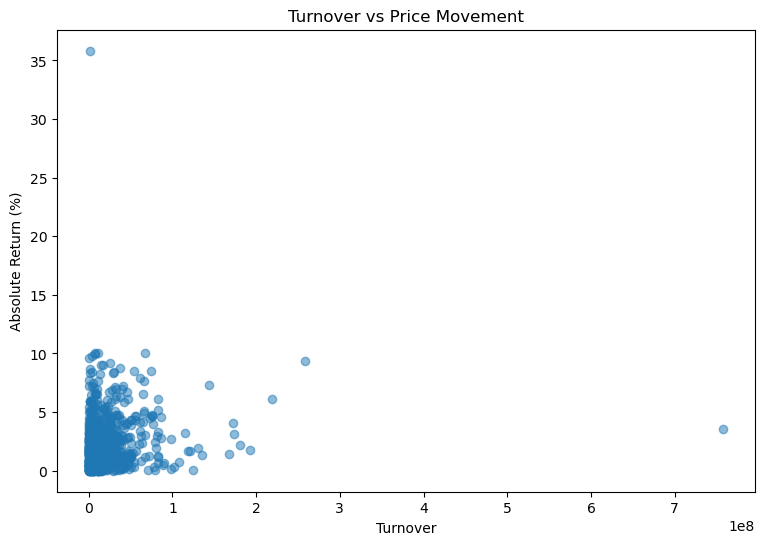

In [83]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df['Turnover'],
    df['Abs_Return'],
    alpha=0.5
)

plt.xlabel('Turnover')
plt.ylabel('Absolute Return (%)')
plt.title('Turnover vs Price Movement')

plt.show()